In [16]:
import cv2
import matplotlib.pyplot as plt

In [17]:
config_file = r"C:\MACHINE LEARNING PROJECTS\Multiple Objects Detection\ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt"

In [18]:
frozen_model = r"C:\MACHINE LEARNING PROJECTS\Multiple Objects Detection\frozen_inference_graph.pb"

In [19]:
model = cv2.dnn_DetectionModel(frozen_model,config_file)

In [20]:
classLabels = []
file_name = r"C:\MACHINE LEARNING PROJECTS\Multiple Objects Detection\person.txt"
with open(file_name,'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')

In [21]:
print(len(classLabels))

80


In [22]:
classLabels

['person',
 'bicycle',
 'car',
 'motorcycle',
 'airplane',
 'bus',
 'train',
 'truck',
 'car',
 'traffic light',
 'fire hydrant',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'backpack',
 'umbrella',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'couch',
 'potted plant',
 'bed',
 'dining table',
 'toilet',
 'TV',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'book',
 'clock',
 'vase',
 'scissors',
 'teddy bear',
 'hair drier',
 'toothbrush']

In [23]:
model.setInputSize(320,320)
model.setInputScale(1.0/127.5)
model.setInputMean((127.5,127,5,127.5))
model.setInputSwapRB(True)

< cv2.dnn.Model 000002C2390D2430>

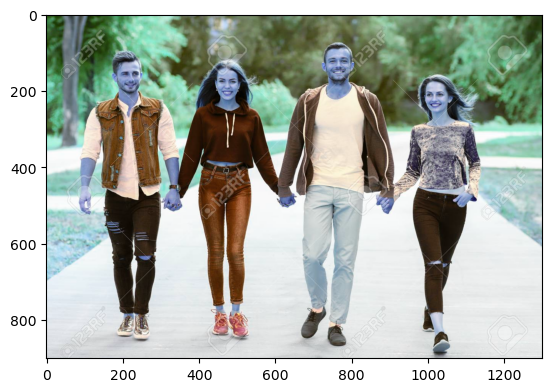

In [24]:
img = cv2.imread(r"C:\MACHINE LEARNING PROJECTS\Multiple Objects Detection\88564945-full-length-portrait-of-young-friends-holding-hands-walking-in-park-four-people-happy-looking-at.jpg")

plt.imshow(img)

In [25]:
ClassIndex , confidece, bbox = model.detect(img,confThreshold=0.5)

In [26]:
print(ClassIndex)

[1 1 1 1]


In [27]:
font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN
for ClassInd,conf,boxes in zip(ClassIndex.flatten(),confidece.flatten(),bbox):
    cv2.rectangle(img,boxes,(255,0,0),2)
    cv2.putText(img,classLabels[ClassInd-1],(boxes[0]+10,boxes[1]+40),font, fontScale = font_scale,color=(1,255,0),thickness = 3)

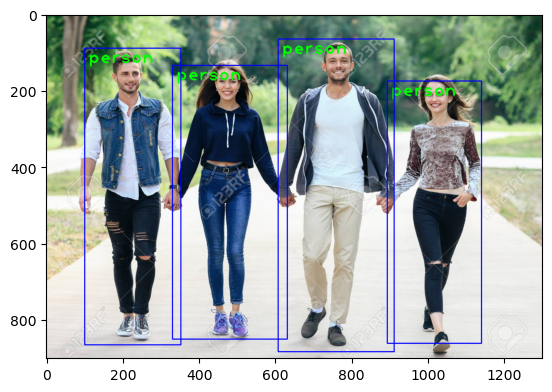

In [28]:
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

In [29]:
import cv2

cap = cv2.VideoCapture(r"C:\MACHINE LEARNING PROJECTS\Multiple Objects Detection\traffic_sound_indian_traffic_sound_traffic_noise_vehicle_noise_t.mp4")

if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise IOError('Video source not opening')

font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN

while True:
    ret, frame = cap.read()
    if not ret:
        break

    ClassIndex, confidence, bbox = model.detect(frame, confThreshold=0.55)
    print(ClassIndex)

    if len(ClassIndex) != 0:
        for ClassInd, conf, boxes in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
            if ClassInd <= 80:
                cv2.rectangle(frame, boxes, (255, 0, 0), 2)
                cv2.putText(frame, classLabels[ClassInd-1],
                            (boxes[0]+10, boxes[1]+40),
                            font, fontScale=font_scale,
                            color=(0, 255, 0), thickness=3)

    cv2.imshow('Object Detection', frame)
    if cv2.waitKey(111) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3 6 8]
[3 8 4]
[4 3]
[4]
[4 1]
[4 1 1]
[4 1]
[1 4]
[4]
[4 1]
[4 1 1]
[4]
[4]
[4 1]
[4]
[4]
[4 1]
[2 1]
[4]
[4 2]
[4 2 1]
[4]
[4]
[4]
[4 1]
[4 1]
[4]
[4]
[4 3]
[3 6 4]
[6 4]
[3 4]
[3]
()
[3]
[3]
[3]
[3]
[3]
[3]
[3]
[3 1]
[3 1]
[3 1]
[3]
[3]
[3]
[3]
[3 1]
[3 1 8]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3 1]
[3]
[3 1]
[3 1 1]
[3 1 1]
[3 1]
[3]
[3]
[3 1]
[3 1]
[3 1]
[3 1 8]
[8]
[8 6]
[8 1 3 1]
[1 8 1]
[8 1 1]
[1 8]
[8]
[8 1]
[8 1]
[8 1 1]
[8 1]
[8 1]
[8 1]
[8]
[8 1]
[8 1 3]
[3 8 1]
[8 1]
[8 1]
[8 1]
[8 1 3]
[8 1]
[8 1]
[8 1]
[8]
[8]
[8 3]
[8 3 1]
[8 3 1]
[8 3 8 1 3]
[8 3 1]
[8 3 1 8]
[3 8 1]
[8 3 1 2]
[3 8 1 3]
[3 8 1 3]
[3 8]
[3 8 1 8]
[3 1 8]
[3 1 8]
[3 8 1]
[3 8 1]
[3 8 3 1]
[8 3 3 1]
[8 3 3]
[8 3]
[8 3]
[8 3]
[8 3]
[3 8]
[8 3 6]
[8 3]
[3 8]
[3 8 1]
[3 8]
[3 8]
[3 8 8]
[3 8 8]
[3 8]
[3 6]
[3 8]
[3 8]
[3 8 8]
[3 8]
[3 8]
[3]
[3 8]
[3 8]
[3]
[3 6]
[3 6]
[3]
[3]
[3 8]
[3]
[3]
[